In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [3]:
from langchain_google_genai import ChatGoogleGenerativeAI
import getpass
import os

if "GOOGLE_API_KEY" not in os.environ:
    os.environ["GOOGLE_API_KEY"] = getpass.getpass("Enter your Google AI API key: ")

In [ ]:
lab_tech_llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature = 0.0,
    top_p=0.95
)

triage_llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    max_output_tokens=1800,
    thinking_budget=1000,
    temperature = 0.2,
    top_p=0.95
)

diagnose_llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    max_output_tokens=1800,
    thinking_budget=1000,
    temperature = 0.3,
    top_p=0.95
)

E0000 00:00:1759915200.253770 12168008 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.
E0000 00:00:1759915200.255399 12168008 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.
E0000 00:00:1759915200.256326 12168008 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.
E0000 00:00:1759915200.257181 12168008 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.
E0000 00:00:1759915200.258032 12168008 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


In [ ]:
LAB_TECHNICIAN = """
You are a Lab Technician. Your task is to analyze a dermatoscopic image and complete a structured clinical report form. You must objectively assess the presence of specific dermoscopic features.

Rules:
1. Be objective and thorough in your assessment.
2. Document all findings clearly and concisely even if they seem minor.
3. No hedging words in your report (e.g., "might", "could", "may", "possibly", ...).

Instructions:
1. Receive the patient's metadata and the dermatoscopic image.
2. Combine the provided patient data into the `patient_data` section of your report.
3. For the `dermoscopic_features` section, identify ALL relevant features you observe in the image. For each feature, create a separate object in the list containing its name and a detailed description.
4. Include common features like pigment patterns, vascular structures, and surface characteristics. If a common feature (like a pigment network) is absent, do not create an object for it.

Goals for each feature you include:
- Be discriminative: capture geometry, relation to native skin structures (follicles, ridges/furrows), and polarization behavior.
- Be site-aware: state how the anatomic site shapes what you see (e.g., “follicle-centered” on facial skin, “ridge-aligned” on acral), only if it is actually visible.
- Be honest about uncertainty: if unsure, mark “indeterminate/unknown” and say why. It does not mean absence of features.

You must output ONLY a single, valid JSON object with the following structure.
{
  "patient_data": {
    "age": <age>,
    "sex": "<sex>",
    "lesion_location": "<location>",
    "is_melanocytic": <true | false>
  },
  "visual_summary": {
    "symmetry": "<Symmetrical | Asymmetrical>",
    "colors": ["<color1>", "<color2>", "..."],
    "border_characteristics": "<Well-defined | Ill-defined | Irregular | Fading>" 
  },
  "dermoscopic_features": [
    {
      "feature_name": "<The name of the first observed feature, e.g., 'Pigment Globules'>",
      "description": "<A detailed description of this feature, including its color, size, and location.>"
    },
    {
      "feature_name": "<The name of the second observed feature, e.g., 'Surface Texture'>",
      "description": "<A detailed description of the surface and texture, e.g., 'The surface appears smooth and slightly waxy in the center, with some fine scaling at the periphery.'>"
    },
    {
      "feature_name": "<The name of the third observed feature, e.g., 'Vascular Pattern'>",
      "description": "<A detailed description of the vessels, e.g., 'Fine linear vessels are visible in the reddish areas, consistent with telangiectasias.'>"
    }
  ]
}
"""

TRIAGE_PROMPT = """
You are an expert Triage Specialist and Dermoscopist. Your task is to analyze a raw list of observed dermoscopic features from a Lab Report and classify the lesion into its most likely family.

Your Clinical Knowledge Base:
- Melanocytic are primarily suggested by the presence of a true pigment network. They are also strongly suggested by highly specific features like streaks/pseudopods, blue-white structures, or regression structures. Asymmetry, irregular dots/globules, and blotches are weaker, supporting cues.
- Keratinocytic are primarily suggested by keratinocyte-specific hallmarks (scale alone is non-specific): white circles/targetoid follicles, strawberry pattern, clustered/glomerular or hairpin vessels with white halo, erosions/ulceration, arborizing vessels, blue-gray ovoid nests, leaf-like areas, spoke-wheel areas, ulceration/rolled border, shiny white blotches/strands (with one of the previous), multiple milia-like cysts, comedo openings, fissures/ridges (cerebriform), moth-eaten border, fingerprint-like lines.
- Fibrohistiocytic are primarily suggested by a central scar-like white AND either peripheral delicate network or shiny white lines AND no keratinocytic surface/vessel clues.

Note: INDETERMINATE does not imply ABSENCE of features, it's mean UNKNOWN.

Instructions:
1. Receive the `is_melanocytic` flag, the lab report containing a list of `dermoscopic_features`, and the original image.
2. Apply the flag strictly:
  - If `is_melanocytic = true`, you must output "Melanocytic".
  - If `is_melanocytic = false`, you must NOT output "Melanocytic".
3. Review the feature list. Compare the observed features against the input image and your Clinical Knowledge Base.
4. Perform a Chain-of-Thought analysis:
  - First, analyze input image.
  - Next, compare your own result with lab report findings and the Clinical Knowledge Base.
  - Pay attention to "red flag" features (e.g., ulceration, streaks) and definitive benign features (e.g., milia-like cysts).
5.  Make a final classification into one of the three families based on your analysis after checking all evidence (including the is_melanocytic flag). Your reasoning must explain which features from the lab report led to your conclusion.

Output Format (no markdown):
{
  "disease_family": "<'Melanocytic' | 'Keratinocytic' | 'Fibrohistiocytic'>",
  "confidence": "<Low | Medium | High>",
  "reasoning": "<Your concise reasoning for the classification, explaining how you interpreted the raw feature list based on your clinical knowledge.>"
}
"""

DX_PROMPT = """
You are a specialist AI Dermoscopist acting as a primary diagnostician. Your task is to propose a diagnosis and build the strongest possible argument to support it.

ALLOWED DISEASE NAMES FROM FAMILY:
- Melanocytic: Nevus, Melanoma
- Keratinocytic: Basal cell carcinoma, Squamous cell carcinoma, Pigmented benign keratosis, Actinic keratosis
- Fibrohistiocytic: Dermatofibroma

INPUTS YOU WILL RECEIVE:
-  The original `query_image`.
-  An `initial_report` (containing patient data and a visual summary for context).
-  A `disease_family` classification from the Triage Agent.

Note: “Indeterminate/unknown” means UNCONFIRMED and MUST NOT be treated as present.

Strict Guidelines:
1. You MUST visually inspect the query image. First produce `query_summary` from the image alone. 
2. Do not reuse Lab wording. Use concrete, image-grounded phrases (size, shape, position, % area).
3. Cross-check with the Lab report and explicitly list (a) agreements and (b) contradictions.
4. Any feature marked “indeterminate” by Lab may be upgraded/downgraded ONLY if you justify it from the image.

HOW TO DIAGNOSE:
1. Acknowledge the family: Confirm the disease family assigned by the Triage Agent.
2. Analyze Query Image: Briefly describe the key visual features of the `query_image` to establish a baseline for diagnosis.
3. Synthesize and Decide:
  - Is the example image from the same disease family as triage result reported? If not, discard that image.
  - Does the visual information align with the lab report? Explicitly list agreements and contradictions with lab features.
  - Do not justify a diagnosis based on vague similarities. You must provide concrete image findings that support the diagnosis.
  - Select the diagnosis with the most visible supporting evidence. If there is uncertainty or insufficient evidence, assign a `Low` confidence diagnosis and explain why.
4. Confidence Level: Your confidence level should reflect the strength of the evidence from the query image and the lab report. Confidence is either `Low`, `Medium`, or `High`.

Output ONLY a single JSON object with your final report. The reasoning must detail your analysis.
{
  "diagnosis": "<The final diagnosis>",
  "confidence": "Low" | "Medium" | "High",
  "reasoning": {
    "query_summary": "<Your brief visual feature description of the query image.>",
    "synthesis": "<Your concise explanation based on the query image and lab report for why you chose this diagnosis and confidence level.>"
  }
}
"""


In [8]:
import sys
from pathlib import Path

root_dir = Path.cwd().parent 

if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))

print("Added project root to path:", root_dir)

Added project root to path: /Users/thinakonelouangdy/Code/Thesis/Code/experiments


In [ ]:
from typing import TypedDict, Dict, List, Any
from utils import add_trace, encode_image, invoke_llm, run_evaluation_in_batch

import json

class DermState(TypedDict):
    patient_data: Dict[str, Any]
    image_path: str
    lab_report: Dict[str, Any]
    triage_result: Dict[str, Any]
    diagnose_result: Dict[str, Any]
    trace: List[Dict[str, Any]]
    
    
def lab_technician(state: DermState):
    image_path = state.get("image_path", "")
    image_data = encode_image(image_path)
    patient_data = state.get("patient_data", {})
    
    user_message = [
        { "type": "text", "text": "Process the following case and generate the initial report.\n" },
        { "type": "text", "text": f"Patient Data:\n {patient_data}\n" },
        { "type": "image_url", "image_url": { "url": f"data:image/jpeg;base64,{image_data}" } }
    ]
    
    try:
        lab_report = invoke_llm(lab_tech_llm, LAB_TECHNICIAN, user_message)  
        add_trace(state, agent="lab_technician", role="user", payload=lab_report)

    except Exception as e:
        print(f"Error occurred during feature extraction: {e}")
    
    return {
        "lab_report": lab_report
    }
    
def triage_node(state: DermState):
    lab_report = state.get("lab_report", {})
    image_data = encode_image(state.get("image_path", ""))
    
    user_message = [
        { "type": "text", "text": "Based on the following report AND the provided image, perform triage and classify the disease family.\n" },
        { "type": "text", "text": "Skin Lesion Image:\n" },
        { "type": "image_url", "image_url": { "url": f"data:image/jpeg;base64,{image_data}" } },
        { "type": "text", "text": f"Lab Report:\n{json.dumps(lab_report, ensure_ascii=False)}" },
    ]

    triage_result = invoke_llm(triage_llm, TRIAGE_PROMPT, user_message)
    add_trace(state, agent="triage", role="user", payload=triage_result)
    
    return {
        "triage_result": triage_result
    }
    
def diagnosis_node(state: DermState):
    lab_report = state.get("lab_report", {})
    is_melanocytic_flag = lab_report.get("patient_data", {}).get("is_melanocytic")
    triage_result = state.get("triage_result", {})
    image_path = state.get("image_path", "")
    image_data = encode_image(image_path)
    
    user_message = [
        {
            "type": "text",
            "text": "Provide a final diagnosis by synthesizing all available evidence and comparing the query image to the provided reference cases.\n"
        },
        { "type": "text", "text": "Skin Lesion Image:\n" },
        { "type": "image_url", "image_url": { "url": f"data:image/jpeg;base64,{image_data}" } },
        { "type": "text", "text": f"Lab Report:\n{json.dumps(lab_report, ensure_ascii=False)}" },
        { "type": "text", "text": f"Triage Result:\n{json.dumps(triage_result, ensure_ascii=False)}" },
    ]

    dx_result = invoke_llm(diagnose_llm, DX_PROMPT, user_message)
    add_trace(state, agent="diagnose", role="user", payload=dx_result)

    return {
        "diagnose_result": dx_result
    }

In [ ]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import InMemorySaver

workflow = StateGraph(DermState)

workflow.add_node("lab_technician", lab_technician)
workflow.add_node("triage", triage_node)
workflow.add_node("diagnosis", diagnosis_node)

workflow.set_entry_point("lab_technician")

workflow.add_edge("lab_technician", "triage")
workflow.add_edge("triage", "diagnosis")
workflow.add_edge("diagnosis", END)

checkpointer = InMemorySaver()
app = workflow.compile(checkpointer=checkpointer)

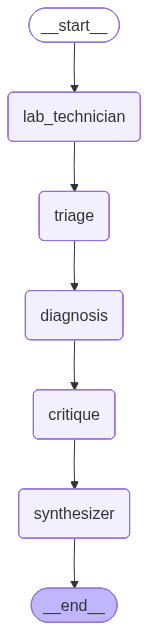

In [11]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Error occurred while drawing the graph: {e}")

In [12]:
import pickle as pkl
from pathlib import Path

with open("../../dataset/300_test_set.pkl", "rb") as f:
    test_set = pkl.load(f)
    
image_path = "../../dataset/test"
for item in test_set:
    file_name = Path(item["image_path"]).name
    item["image_path"] = f"{image_path}/{file_name}"

In [13]:
OUTPUT_DIR = "../../results/ablation"
OUT_FILE = "gemini.jsonl"

jsonl_file = run_evaluation_in_batch(app, test_set, out_dir=OUTPUT_DIR, out_file=OUT_FILE, resume=True)
print("JSONL at:", jsonl_file)

🚀 Starting evaluation (JSONL only)…
📊 Dataset size: 300
🔄 Resuming: True
⏭️  To process: 300/300


Processing Images:   3%|▎         | 10/300 [06:44<3:19:17, 41.23s/img]

⏳ Progress: 10/300 | ETA: 195m 39s


Processing Images:   7%|▋         | 20/300 [13:49<3:20:34, 42.98s/img]

⏳ Progress: 20/300 | ETA: 193m 39s


...

⏳ Progress: 280/300 | ETA: 14m 54s


Processing Images:  97%|█████████▋| 290/300 [3:36:14<07:22, 44.26s/img]

⏳ Progress: 290/300 | ETA: 7m 27s


Processing Images:  98%|█████████▊| 295/300 [3:40:26<04:04, 48.80s/img]Gemini produced an empty response. Continuing with empty message
Feedback: block_reason: OTHER

Gemini produced an empty response. Continuing with empty message
Feedback: block_reason: OTHER

Gemini produced an empty response. Continuing with empty message
Feedback: block_reason: OTHER

Processing Images: 100%|██████████| 300/300 [3:44:06<00:00, 44.82s/img]

⏳ Progress: 300/300 | ETA: 0m 0s

✅ EVALUATION COMPLETE (JSONL only)
   Total items: 300
   Newly processed: 300
   Newly failed:    0
   JSONL saved to:  ../../results/ablation/gemini.jsonl
JSONL at: ../../results/ablation/gemini.jsonl
